# Naive Bayes: Retail vs Credit Card Comparison

This notebook compares the Gaussian Naive Bayes model performance on both datasets:

- Online Retail dataset — high-value vs low-value customer classification
- Credit Card Fraud dataset — normal vs fraudulent transaction detection

The aim is to understand how the same model behaved on two different classification tasks and identify where it performed well and where it struggled.

In [2]:
# =====================================================
# 1. LOAD NAIVE BAYES RESULTS
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nb_retail_results = pd.read_csv("../results/Naive_Bayes_retail_results.csv")
nb_credit_results = pd.read_csv("../results/Naive_Bayes_credit_results.csv")

nb_comparison = pd.concat(
    [nb_retail_results, nb_credit_results],
    ignore_index=True
)

metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

display(nb_comparison.round(3))

,Dataset,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Online Retail,Gaussian Naive Bayes,0.964,0.932,0.925,0.928,0.992
1,Credit Card Fraud,Gaussian Naive Bayes,0.980,0.173,0.933,0.292,0.989


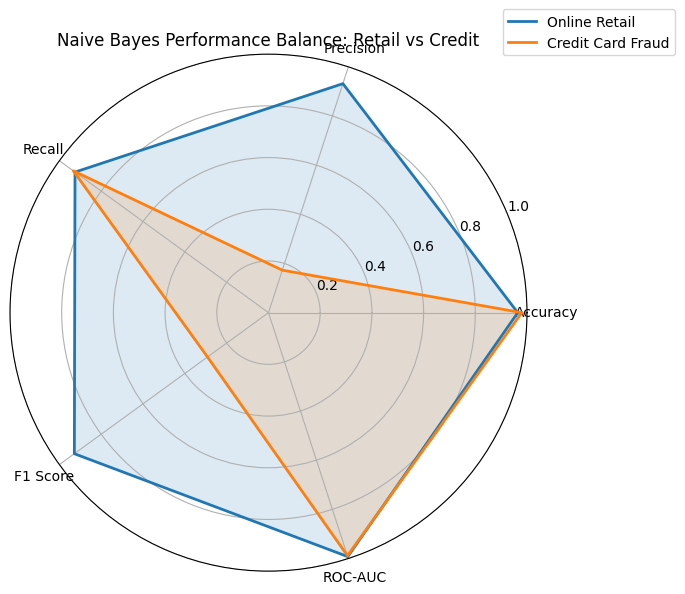

In [3]:
# =====================================================
# 2. NAIVE BAYES RADAR CHART COMPARISON
# =====================================================

angles = np.linspace(
    0,
    2 * np.pi,
    len(metrics),
    endpoint=False
).tolist()

angles += angles[:1]

plt.figure(figsize=(7, 7))

ax = plt.subplot(111, polar=True)

for _, row in nb_comparison.iterrows():

    values = row[metrics].tolist()
    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=row["Dataset"]
    )

    ax.fill(
        angles,
        values,
        alpha=0.15
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)

plt.title("Naive Bayes Performance Balance: Retail vs Credit")
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

,Dataset,Model,Metric,Score
9,Credit Card Fraud,Gaussian Naive Bayes,ROC-AUC,0.989
1,Credit Card Fraud,Gaussian Naive Bayes,Accuracy,0.980
5,Credit Card Fraud,Gaussian Naive Bayes,Recall,0.933
7,Credit Card Fraud,Gaussian Naive Bayes,F1 Score,0.292
3,Credit Card Fraud,Gaussian Naive Bayes,Precision,0.173
8,Online Retail,Gaussian Naive Bayes,ROC-AUC,0.992
0,Online Retail,Gaussian Naive Bayes,Accuracy,0.964
2,Online Retail,Gaussian Naive Bayes,Precision,0.932
6,Online Retail,Gaussian Naive Bayes,F1 Score,0.928
4,Online Retail,Gaussian Naive Bayes,Recall,0.925


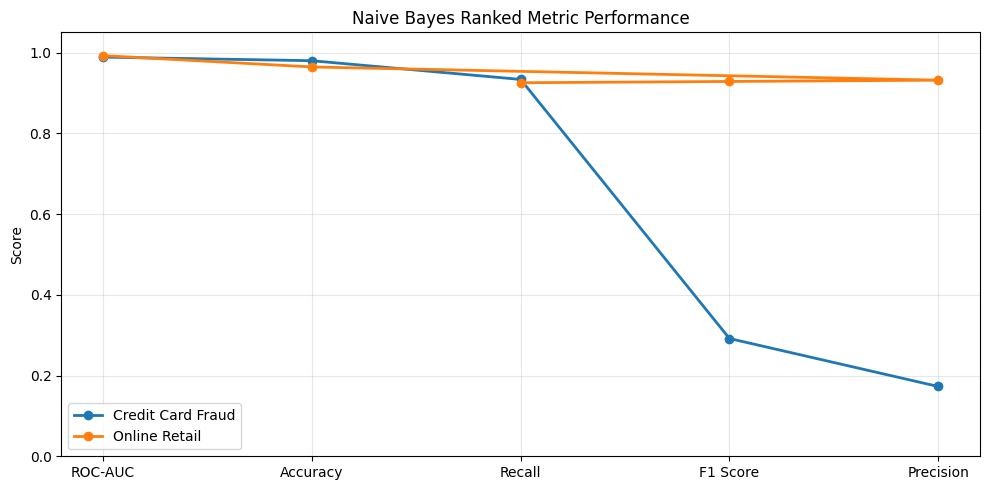

In [4]:
# =====================================================
# 3. NAIVE BAYES METRIC RANKING PLOT
# =====================================================

ranked_nb = nb_comparison.melt(
    id_vars=["Dataset", "Model"],
    value_vars=metrics,
    var_name="Metric",
    value_name="Score"
)

ranked_nb = ranked_nb.sort_values(
    by=["Dataset", "Score"],
    ascending=[True, False]
)

display(ranked_nb.round(3))

plt.figure(figsize=(10, 5))

for dataset in ranked_nb["Dataset"].unique():

    subset = ranked_nb[ranked_nb["Dataset"] == dataset]

    plt.plot(
        subset["Metric"],
        subset["Score"],
        marker="o",
        linewidth=2,
        label=dataset
    )

plt.title("Naive Bayes Ranked Metric Performance")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

,Metric,Retail - Credit Gap
0,Accuracy,-0.015
1,Precision,0.759
2,Recall,-0.008
3,F1 Score,0.637
4,ROC-AUC,0.004


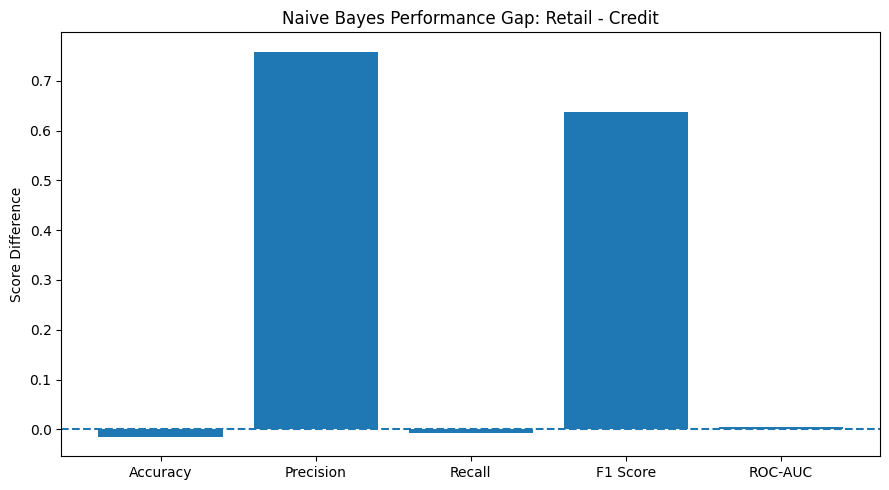

In [5]:
# =====================================================
# 4. NAIVE BAYES PERFORMANCE GAP CHART
# =====================================================

retail_scores = nb_comparison[
    nb_comparison["Dataset"] == "Online Retail"
][metrics].iloc[0]

credit_scores = nb_comparison[
    nb_comparison["Dataset"] == "Credit Card Fraud"
][metrics].iloc[0]

gap_df = pd.DataFrame({
    "Metric": metrics,
    "Retail - Credit Gap": retail_scores.values - credit_scores.values
})

display(gap_df.round(3))

plt.figure(figsize=(9, 5))

plt.bar(
    gap_df["Metric"],
    gap_df["Retail - Credit Gap"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Naive Bayes Performance Gap: Retail - Credit")
plt.ylabel("Score Difference")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

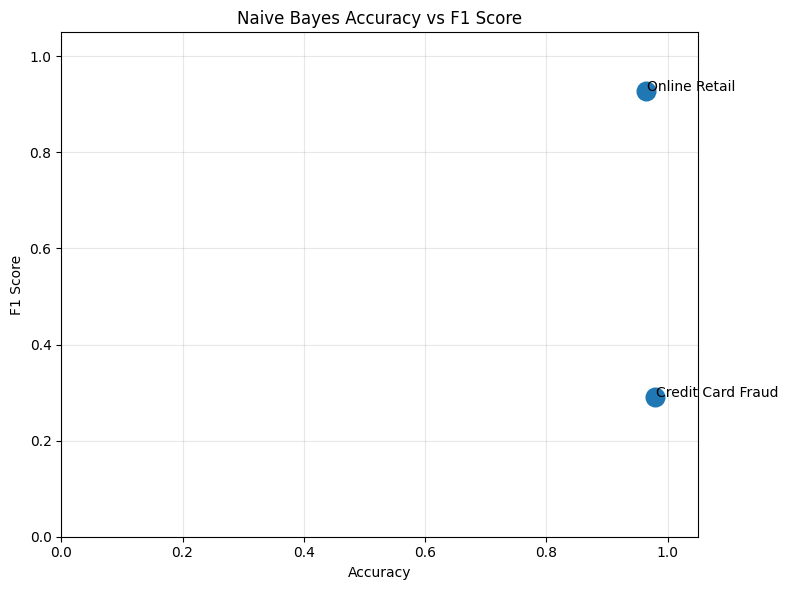

In [6]:
# =====================================================
# 5. ACCURACY VS F1 SCORE SCATTER PLOT
# =====================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    nb_comparison["Accuracy"],
    nb_comparison["F1 Score"],
    s=180
)

for _, row in nb_comparison.iterrows():
    plt.text(
        row["Accuracy"] + 0.002,
        row["F1 Score"],
        row["Dataset"],
        fontsize=10
    )

plt.title("Naive Bayes Accuracy vs F1 Score")
plt.xlabel("Accuracy")
plt.ylabel("F1 Score")
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

,Dataset,F1 Score,ROC-AUC,Naive Bayes Strength Index
0,Online Retail,0.928,0.992,0.954
1,Credit Card Fraud,0.292,0.989,0.570


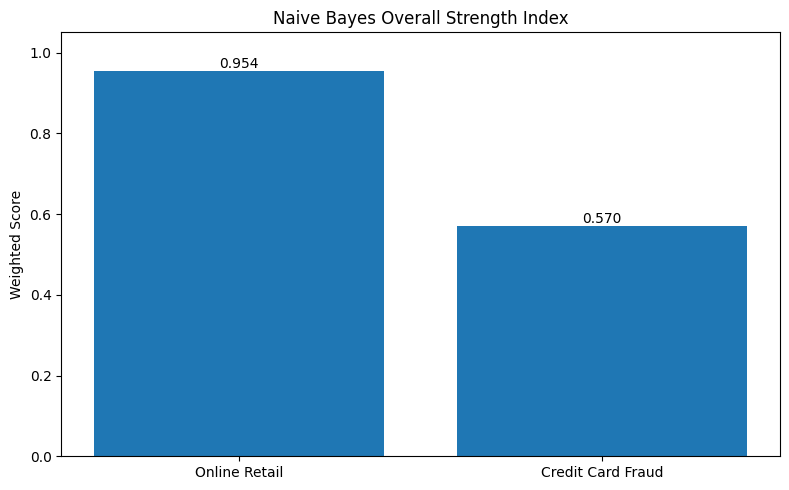

In [7]:
# =====================================================
# 6. NAIVE BAYES STRENGTH INDEX
# =====================================================

strength_df = nb_comparison.copy()

strength_df["Naive Bayes Strength Index"] = (
    strength_df["F1 Score"] * 0.6 +
    strength_df["ROC-AUC"] * 0.4
)

display(
    strength_df[
        [
            "Dataset",
            "F1 Score",
            "ROC-AUC",
            "Naive Bayes Strength Index"
        ]
    ].round(3)
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    strength_df["Dataset"],
    strength_df["Naive Bayes Strength Index"]
)

plt.title("Naive Bayes Overall Strength Index")
plt.ylabel("Weighted Score")
plt.ylim(0, 1.05)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [8]:
# =====================================================
# 7. RETAIL VS CREDIT PERFORMANCE DIFFERENCE
# =====================================================

retail_scores = nb_comparison[
    nb_comparison["Dataset"] == "Online Retail"
][metrics].iloc[0]

credit_scores = nb_comparison[
    nb_comparison["Dataset"] == "Credit Card Fraud"
][metrics].iloc[0]

difference_df = pd.DataFrame({
    "Metric": metrics,
    "Retail Score": retail_scores.values,
    "Credit Score": credit_scores.values,
    "Difference": retail_scores.values - credit_scores.values
})

display(difference_df.round(3))

,Metric,Retail Score,Credit Score,Difference
0,Accuracy,0.964,0.980,-0.015
1,Precision,0.932,0.173,0.759
2,Recall,0.925,0.933,-0.008
3,F1 Score,0.928,0.292,0.637
4,ROC-AUC,0.992,0.989,0.004


,F1 Score,ROC-AUC
Dataset,,
Online Retail,0.928,0.992
Credit Card Fraud,0.292,0.989


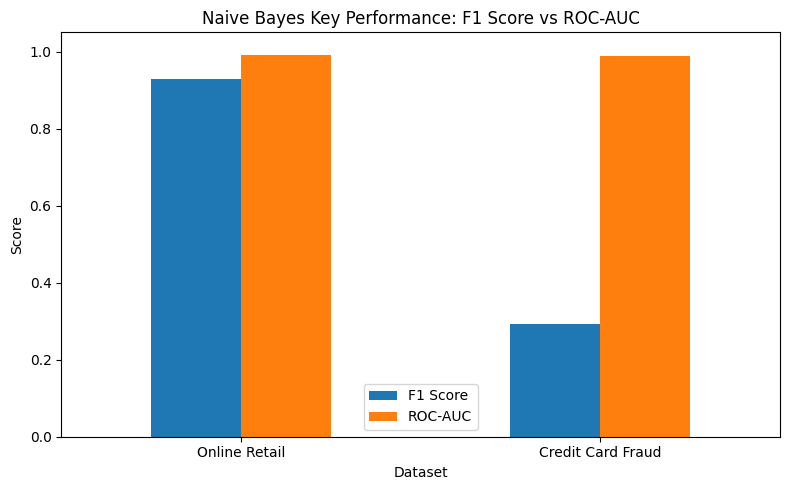

In [9]:
# =====================================================
# 8. F1 SCORE AND ROC-AUC FOCUS CHART
# =====================================================

focus_metrics = [
    "F1 Score",
    "ROC-AUC"
]

focus_df = nb_comparison[
    ["Dataset"] + focus_metrics
].set_index("Dataset")

display(focus_df.round(3))

focus_df.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Naive Bayes Key Performance: F1 Score vs ROC-AUC")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

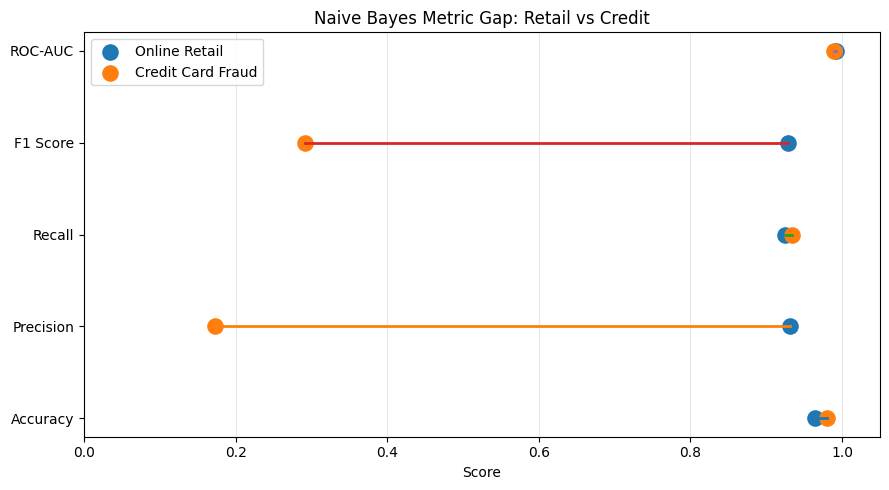

In [10]:
# =====================================================
# 9. DUMBBELL CHART — METRIC GAP
# =====================================================

retail_scores = nb_comparison[
    nb_comparison["Dataset"] == "Online Retail"
][metrics].iloc[0]

credit_scores = nb_comparison[
    nb_comparison["Dataset"] == "Credit Card Fraud"
][metrics].iloc[0]

y_positions = np.arange(len(metrics))

plt.figure(figsize=(9, 5))

for i in range(len(metrics)):
    plt.plot(
        [retail_scores.values[i], credit_scores.values[i]],
        [y_positions[i], y_positions[i]],
        linewidth=2
    )

plt.scatter(
    retail_scores.values,
    y_positions,
    s=120,
    label="Online Retail"
)

plt.scatter(
    credit_scores.values,
    y_positions,
    s=120,
    label="Credit Card Fraud"
)

plt.yticks(y_positions, metrics)
plt.xlabel("Score")
plt.title("Naive Bayes Metric Gap: Retail vs Credit")
plt.xlim(0, 1.05)
plt.legend()
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# =====================================================
# 10. BEST DATASET BASED ON F1-SCORE
# =====================================================

best_dataset = nb_comparison.sort_values(
    by="F1 Score",
    ascending=False
).iloc[0]

print("=" * 60)
print("BEST DATASET FOR NAIVE BAYES MODEL")
print("=" * 60)

print(f"Dataset      : {best_dataset['Dataset']}")
print(f"Model        : {best_dataset['Model']}")
print(f"F1 Score     : {best_dataset['F1 Score']:.3f}")
print(f"Accuracy     : {best_dataset['Accuracy']:.3f}")
print(f"Precision    : {best_dataset['Precision']:.3f}")
print(f"Recall       : {best_dataset['Recall']:.3f}")
print(f"ROC-AUC      : {best_dataset['ROC-AUC']:.3f}")

print("\nConclusion:")
print(
    f"The Naive Bayes model performed best on the {best_dataset['Dataset']} dataset "
    f"based on the highest F1-score of {best_dataset['F1 Score']:.3f}."
)

best_dataset_table = pd.DataFrame([best_dataset])

display(
    best_dataset_table[
        [
            "Dataset",
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC"
        ]
    ].round(3)
)

BEST DATASET FOR NAIVE BAYES MODEL
Dataset      : Online Retail
Model        : Gaussian Naive Bayes
F1 Score     : 0.928
Accuracy     : 0.964
Precision    : 0.932
Recall       : 0.925
ROC-AUC      : 0.992

Conclusion:
The Naive Bayes model performed best on the Online Retail dataset based on the highest F1-score of 0.928.


,Dataset,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Online Retail,Gaussian Naive Bayes,0.964,0.932,0.925,0.928,0.992


In [12]:
# =====================================================
# 11. SAVE NAIVE BAYES COMPARISON RESULTS
# =====================================================

nb_comparison.to_csv(
    "../results/Naive_Bayes_retail_credit_comparison.csv",
    index=False
)

print("Naive Bayes comparison results saved successfully.")

from google.colab import files
files.download("../results/Naive_Bayes_retail_credit_comparison.csv")

Naive Bayes comparison results saved successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Overall Summary of the Comparison

The comparison table shows that the Gaussian Naive Bayes model performed very differently on the two datasets.

For the **Online Retail dataset**, the model achieved strong results across all metrics. Accuracy was **0.964**, Precision was **0.932**, Recall was **0.925**, F1-score was **0.928**, and ROC-AUC was **0.992**. This shows that Naive Bayes was effective at identifying high-value customers from RFM-based features.

For the **Credit Card Fraud dataset**, the model showed a very different pattern. Accuracy remained high at **0.979** because normal transactions dominated the dataset. However, Precision was very low, meaning many normal transactions were incorrectly flagged as fraud. This caused the F1-score to be low despite a strong ROC-AUC, indicating that the model had good class separation ability but struggled with the imbalanced decision boundary.

The biggest difference between the two datasets was in **Precision** and **F1-score**, which were much higher for the retail dataset. This is because customer value classification is a more balanced and structured problem compared to fraud detection, where fraudulent transactions are extremely rare.

The radar chart, dumbbell chart, and performance gap chart all confirmed that Naive Bayes was a strong baseline for the retail dataset but required additional techniques such as threshold adjustment or resampling to be practical for fraud detection.

Overall, Gaussian Naive Bayes worked well where features were more independent and classes were reasonably balanced, but its independence assumption and sensitivity to class imbalance limited its effectiveness on the credit card fraud dataset.